   connection_duration  protocol_type   service      flag  packet_size  \
0             0.572938       0.458179 -0.742805 -1.638336    -1.106317   
1            -1.254176       0.881647  0.256858  0.006942    -1.722298   
2            -0.350527      -1.318999  1.638336 -0.388758    -0.834389   
3             1.344574      -1.062142  0.617847  0.583137    -0.046772   
4            -0.496146      -0.701152 -1.450899 -0.485947     0.093097   

   error_rate  label  
0   -0.582430      1  
1    0.769317      0  
2    1.654710      1  
3   -1.174009      1  
4   -2.139926      1  


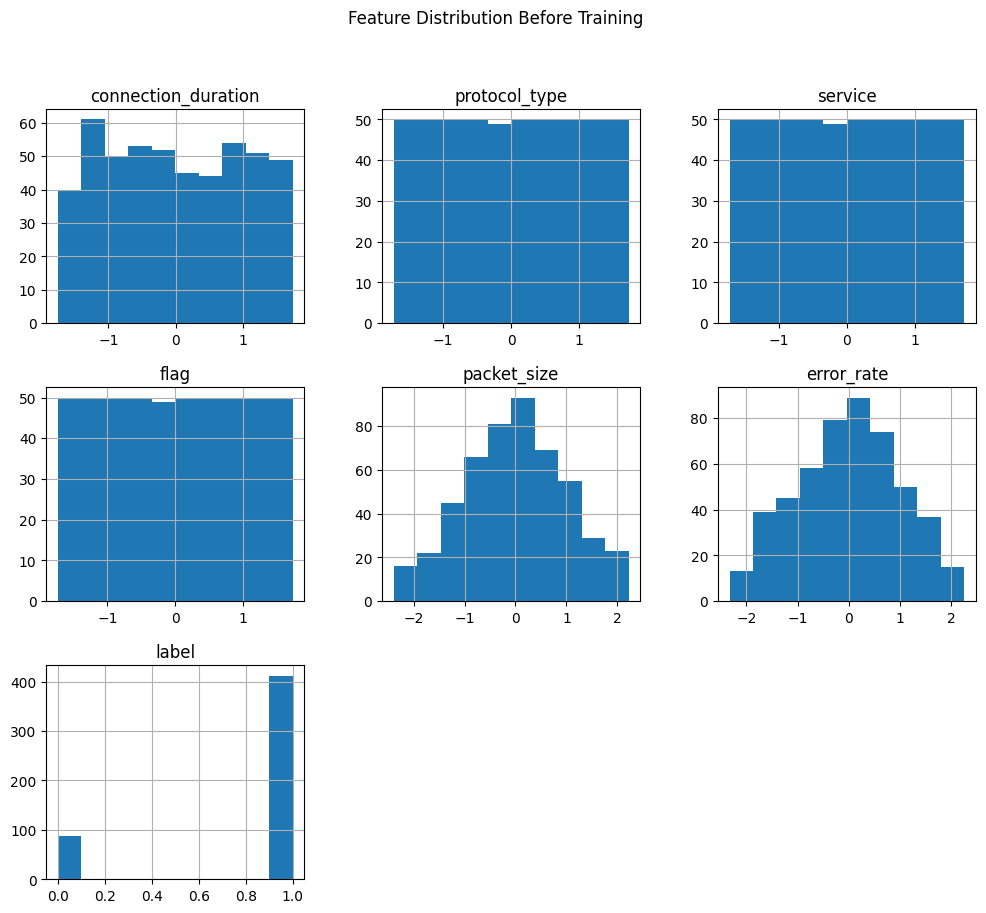

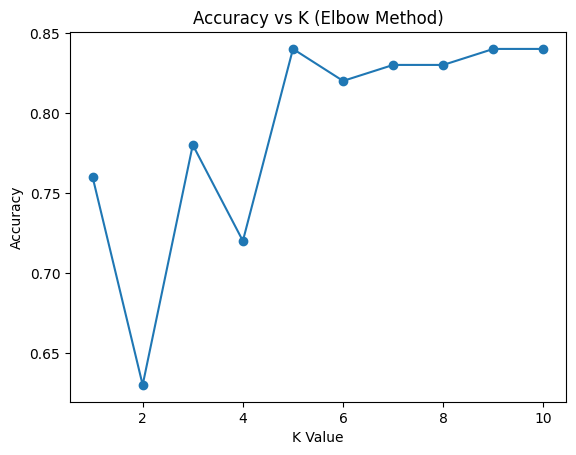

Accuracy : 0.84
Precision : 0.8484848484848485
Recall : 0.9882352941176471
F1 Score : 0.9130434782608695

Confusion Matrix:
 [[ 0 15]
 [ 1 84]]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

df = pd.read_csv(r"D:\PBL AI ML\cleaned_nsl_kdd.csv")

print(df.head())

df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution Before Training")
plt.show()

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

accuracy_list = []

for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, pred_i))

plt.plot(range(1, 11), accuracy_list, marker='o')
plt.title("Accuracy vs K (Elbow Method)")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)